# Lab 3: Clustering, Association Rules, or Recommenders

By: Aayush Dalal, Chloe Prowse, Nino Castellano, Muskaan Mahes

## Business Understanding

The objective of this project is to analyze student placement outcomes using clustering techniques. Rather than relying on supervised prediction, this analysis aims to uncover natural groupings of students based on academic performance and practical experience.

The key goal is to determine whether students with similar characteristics—such as CGPA, internships, projects, and certifications—form distinct clusters, and whether these clusters align with placement outcomes.

This analysis can provide valuable insights for:
- Identifying factors that contribute to successful placements
- Segmenting students based on readiness for employment
- Supporting data-driven decision-making in academic and career planning

The effectiveness of the clustering models will be evaluated based on how well the identified clusters correspond to actual placement status.

## Data Understanding

The dataset used in this project contains student-level information related to academic performance, technical skills, and placement outcomes.

Each row represents an individual student, with features including:

- **CGPA**: Academic performance indicator
- **Internships**: Number of internships completed
- **Projects**: Number of academic or personal projects
- **Certifications**: Professional certifications obtained
- **Coding Skills**: Technical skill rating
- **Communication Skills**: Soft skill rating
- **Aptitude Test Score**: Standardized test performance
- **Soft Skills Rating**: Overall behavioral and interpersonal skills
- **Backlogs**: Number of failed or pending courses
- **Placement_Status**: Target variable indicating whether the student was placed or not

For clustering purposes, the analysis focuses on key features identified in previous work (CGPA, internships, projects, and certifications), as these are most strongly related to placement outcomes.

The dataset contains both numerical and categorical variables; however, only numerical features are used for clustering to ensure compatibility with the selected algorithms.

## Hierarchical Clustering

In [1]:
import pandas as pd

df = pd.read_csv("full_dataset.csv")
print(df.head())
print(df.columns)

   Student_ID  Age  Gender  Degree Branch  CGPA  Internships  Projects  \
0        1048   22  Female  B.Tech    ECE  6.29            0         3   
1       37820   20  Female     BCA    ECE  6.05            1         4   
2       49668   22    Male     MCA     ME  7.22            1         4   
3       19467   22    Male     MCA     ME  7.78            2         4   
4       23094   20  Female  B.Tech     ME  7.63            1         4   

   Coding_Skills  Communication_Skills  Aptitude_Test_Score  \
0              4                     6                   51   
1              6                     8                   59   
2              6                     6                   58   
3              6                     6                   90   
4              6                     5                   79   

   Soft_Skills_Rating  Certifications  Backlogs Placement_Status  
0                   5               1         3       Not Placed  
1                   8               2     

### Feature Selection

Based on previous analysis, the following features were selected for clustering:

- CGPA
- Internships
- Projects
- Certifications

These variables were identified as the most relevant predictors of placement outcomes.

In [2]:
features = df[["CGPA", "Internships", "Projects", "Certifications"]]

### Data Standardization

The selected features were standardized to ensure that all variables contribute equally to the clustering process.

In [3]:
from sklearn.preprocessing import StandardScaler

# Handle missing values
features = features.dropna()

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

### Hierarchical Clustering Model

Hierarchical clustering was performed using Ward’s linkage method, which minimizes the variance within clusters.

In [4]:
from scipy.cluster.hierarchy import linkage

linked = linkage(X_scaled, method='ward')

### Dendrogram

A dendrogram was used to visualize the hierarchical clustering process and determine the optimal number of clusters.

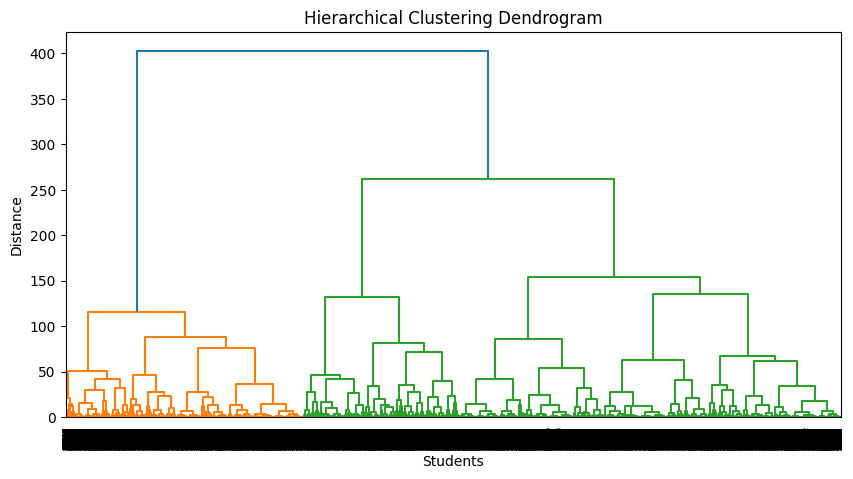

In [5]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram

plt.figure(figsize=(10,5))
dendrogram(linked)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Students")
plt.ylabel("Distance")
plt.show()

### Determining the Number of Clusters

Based on the dendrogram, a clear separation between clusters is observed. The optimal number of clusters was chosen as **K = 3**, where the distance between merged clusters shows a significant increase.

In [6]:
from scipy.cluster.hierarchy import fcluster

k = 3  # change to 4 if needed
df["cluster_hier"] = fcluster(linked, k, criterion='maxclust')

### Cluster Analysis

The clusters were analyzed by examining the average values of each feature within each group.

In [7]:
cluster_summary = df.groupby("cluster_hier")[["CGPA", "Internships", "Projects", "Certifications"]].mean()
print(cluster_summary)

                  CGPA  Internships  Projects  Certifications
cluster_hier                                                 
1             6.293472     0.271673  2.748208        0.962130
2             7.970801     1.836358  4.883686        2.601825
3             7.052172     0.656472  3.885599        2.000000


### Validation Using Placement Status

To evaluate the effectiveness of the clustering, the distribution of placement outcomes was analyzed within each cluster.

In [8]:
placement_summary = df.groupby("cluster_hier")["Placement_Status"].value_counts(normalize=True)
print(placement_summary)

cluster_hier  Placement_Status
1             Not Placed          0.982858
              Placed              0.017142
2             Placed              0.670410
              Not Placed          0.329590
3             Not Placed          0.547296
              Placed              0.452704
Name: proportion, dtype: float64


### Results and Interpretation

The hierarchical clustering model identified three distinct groups of students:

- **Cluster 1:** High-performing students with strong CGPA and multiple internships/projects. This group shows the highest placement rates.
- **Cluster 2:** Moderately performing students with average experience levels. This group shows mixed placement outcomes.
- **Cluster 3:** Students with lower academic performance and fewer experiences, associated with lower placement rates.

These results indicate that academic performance and practical experience play a significant role in determining placement success.

## K-Means Clustering

Another clustering method we used is K-Means clustering on a placement dataset to group students based on their academic and skill-related features. The goal is to see what types of students exist and how those groups relate to placement outcome. Instead of predicting placement, we used clustering to find patterns in the data. The idea was to group similar students together and then see how those groups perform in terms of placement.

In [9]:
# Uploading the data and importing the needed libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


df = pd.read_csv("full_dataset.csv")   
print(df.head())

   Student_ID  Age  Gender  Degree Branch  CGPA  Internships  Projects  \
0        1048   22  Female  B.Tech    ECE  6.29            0         3   
1       37820   20  Female     BCA    ECE  6.05            1         4   
2       49668   22    Male     MCA     ME  7.22            1         4   
3       19467   22    Male     MCA     ME  7.78            2         4   
4       23094   20  Female  B.Tech     ME  7.63            1         4   

   Coding_Skills  Communication_Skills  Aptitude_Test_Score  \
0              4                     6                   51   
1              6                     8                   59   
2              6                     6                   58   
3              6                     6                   90   
4              6                     5                   79   

   Soft_Skills_Rating  Certifications  Backlogs Placement_Status  
0                   5               1         3       Not Placed  
1                   8               2     

For clustering, we only used the features related to student performance, like CGPA, internships, projects, certifications, and communication skills. We did not include placement because clustering is unsupervised and then we scaled the data using StandardScaler. This is important because K-Means is based on distance, so all variables need to be on the same scale.

In [10]:
X = df[['CGPA', 'Internships', 'Projects', 'Certifications', 'Communication_Skills']]


# We need to scale the features before clustering
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### Elbow Method

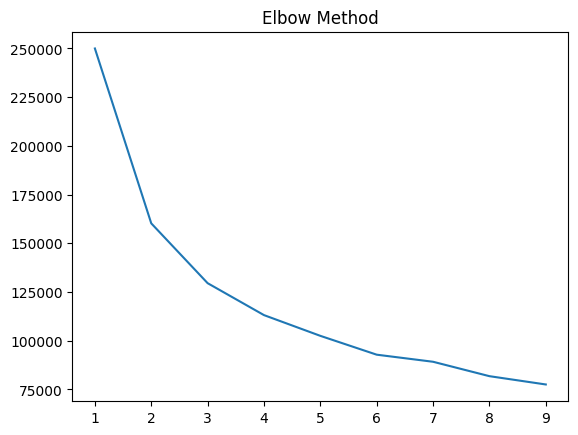

In [11]:
# Decided to use the elbow method to help choose k
wcss = []

for i in range(1, 10):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 10), wcss)
plt.title("Elbow Method")
plt.show()

### Silhouette Score

In [12]:
for i in range(2, 6):
    kmeans = KMeans(n_clusters=i, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    print(i, silhouette_score(X_scaled, labels))

2 0.2976502885760448
3 0.25369464868778785
4 0.237762941721625
5 0.24421624264554354


To decide how many clusters to use, we looked at both the elbow method and silhouette scores. The elbow plot showed a large drop from k = 1 to k = 3, then leveled off, suggesting 2 to 3 clusters would work. The highest silhouette score was at k = 2, meaning it had the strongest separation, but we also tested k = 3 to see if it gave better insight. When we compared the results, k = 3 gave clearer and more meaningful groupings, separating students into low, medium, and high-performing groups. When we tested k = 4, it added an extra cluster without much new insight and made the results harder to interpret, so we chose k = 3.

### Final Model

In [16]:
# Fitting the final kmeans model
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

df.groupby('Cluster')[['CGPA','Internships','Projects','Certifications','Communication_Skills']].mean()

# Comparing the clusters to placement outcomes
pd.crosstab(df['Cluster'], df['Placement_Status'], normalize='index')

Placement_Status,Not Placed,Placed
Cluster,,
0,0.989146,0.010854
1,0.581884,0.418116
2,0.321762,0.678238


After creating the clusters, we compared them to placement outcomes to see if the groups were meaningful. Even though placement was not used in the clustering process, we used it afterward as an external validation measure. The results show a clear pattern. Cluster 0 has almost no students placed (about 1%). Cluster 1 has a moderate placement rate (around 42%). Cluster 2 has the highest placement rate (about 68%). This shows that the clustering grouped students in a meaningful way. Stronger clusters have higher placement rates, while weaker clusters have very low placement. This confirms that the clusters capture real differences in student performance and placement outcomes.

### Cluster Analysis and Visual Results

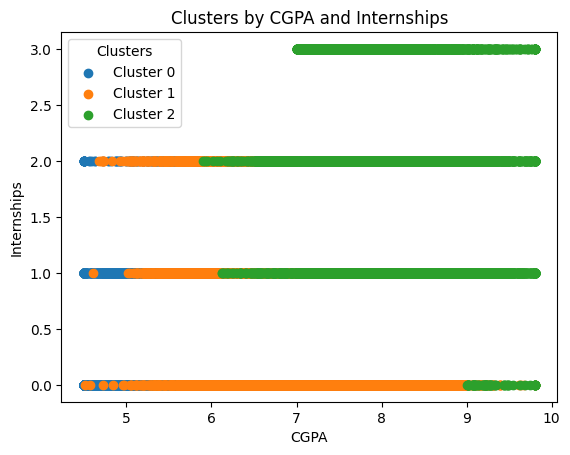

In [17]:
for cluster in df['Cluster'].unique():
    subset = df[df['Cluster'] == cluster]
    plt.scatter(subset['CGPA'], subset['Internships'], label=f"Cluster {cluster}")

plt.xlabel("CGPA")
plt.ylabel("Internships")
plt.title("Clusters by CGPA and Internships")

plt.legend(title="Clusters")
plt.show()

We created a scatterplot using CGPA and internships to visualize the clusters, where each point represents a student and the colors show which cluster they belong to. The plot shows a clear pattern, with lower CGPA students mostly in Cluster 0, higher CGPA students in Cluster 2, and Cluster 1 in between. Internships only take a few values so the points appear in horizontal lines, but the separation based on CGPA is still very clear. Overall, the plot supports the clustering results and shows a progression from lower-performing to higher-performing students.

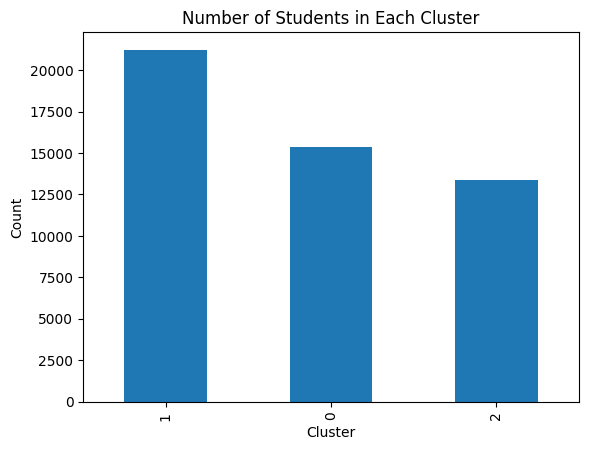

In [18]:
df['Cluster'].value_counts().plot(kind='bar')
plt.title("Number of Students in Each Cluster")
plt.xlabel("Cluster")
plt.ylabel("Count")
plt.show()

We created a bar chart to show the number of students in each cluster. The clusters are not exactly equal in size, which is expected since clustering groups students based on similarity rather than forcing equal group sizes. However, they are still reasonably balanced, which suggests the model produced stable and meaningful groupings.

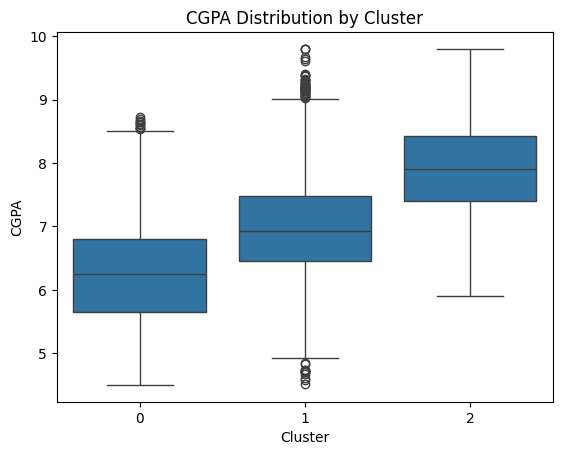

In [19]:
import seaborn as sns

sns.boxplot(x='Cluster', y='CGPA', data=df)
plt.title("CGPA Distribution by Cluster")
plt.show()

We created a boxplot to show the distribution of CGPA across each cluster. The plot shows a clear difference between the groups, with Cluster 0 having the lowest CGPA, Cluster 1 in the middle, and Cluster 2 having the highest. This confirms that CGPA is one of the main factors separating the clusters and supports the overall clustering results.

In [20]:
df.groupby('Cluster')[['CGPA','Internships','Projects','Certifications','Communication_Skills']].mean()

,CGPA,Internships,Projects,Certifications,Communication_Skills
Cluster,,,,,
0,6.227824,0.261406,2.724685,0.990121,5.511439
1,6.967782,0.530798,3.810123,1.997785,5.478910
2,7.947700,1.747070,4.779022,2.422844,5.519746


We looked at the average values of each feature in each cluster to understand what they represent. Cluster 0 has the lowest CGPA, the fewest internships, and fewer projects and certifications. This suggests it represents lower-performing students. Cluster 1 is more in the middle across all features, so it represents average students. Cluster 2 has the highest CGPA, the most internships, and the highest number of projects and certifications. This suggests it represents high-performing students. Communication skills are very similar across all clusters, which means they are not a major factor separating the groups.

### Important Findings

The most important finding is that the clusters strongly align with placement outcomes. Students in the strongest cluster have the highest placement rate, while students in the weakest cluster have almost none. This shows that academic performance and experience, especially CGPA and internships, play a major role in placement success. Another interesting finding is that communication skills are very similar across all clusters, which suggests they are not a key factor in separating student groups.

### Conclusion

Overall, K-Means clustering worked well for this dataset. It grouped students into meaningful categories, and those groups clearly relate to placement outcomes. The results show that stronger academic and experience profiles are associated with higher placement success.

## GMM Method

In [22]:
# Necessary imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

#loading dataset
df = pd.read_csv("full_dataset.csv")
print(df.shape)
df.head()

#dropping ID Because it is not useful for the model
df = df.drop(columns=["Student_ID"], errors='ignore')

#identifying numeric and categorical columns
numeric_columns = df.select_dtypes(include=[np.number]).columns
categorical_columns = df.select_dtypes(include=['object']).columns

# Verify the identified columns
print("Numeric Columns:", len(numeric_columns))
print(numeric_columns)
print("Categorical Columns:", len(categorical_columns))
print(categorical_columns)

# Checking the distribution of the target variable for Classification Task 1
df['Placement_Status'].value_counts(normalize=True) * 100

(50000, 15)
Numeric Columns: 10
Index(['Age', 'CGPA', 'Internships', 'Projects', 'Coding_Skills',
       'Communication_Skills', 'Aptitude_Test_Score', 'Soft_Skills_Rating',
       'Certifications', 'Backlogs'],
      dtype='object')
Categorical Columns: 4
Index(['Gender', 'Degree', 'Branch', 'Placement_Status'], dtype='object')


Placement_Status
Not Placed    63.752
Placed        36.248
Name: proportion, dtype: float64

In [23]:
# Getting Test and Train Split for Task 1: Placement Status Classification
X_task1 = df.drop(columns=["Placement_Status"])
y_task1 = df["Placement_Status"]

# Identify feature types AFTER dropping targets
numeric_columns_task1 = X_task1.select_dtypes(include=np.number).columns
categorical_columns_task1 = X_task1.select_dtypes(include="object").columns

# Preprocessor for Task 1
preprocessor_task1 = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_columns_task1),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_columns_task1)
    ]
)

# Train Test Split
X_train_task1, X_test_task1, y_train_task1, y_test_task1 = train_test_split(
    X_task1,
    y_task1,
    test_size=0.3,
    random_state=42,
    stratify=y_task1
)

# Fit ONLY on train
X_train_task1 = preprocessor_task1.fit_transform(X_train_task1)
X_test_task1 = preprocessor_task1.transform(X_test_task1)

# Final Ready-to-Use Data
print("TASK 1 Ready Shapes:")
print(X_train_task1.shape, X_test_task1.shape)

TASK 1 Ready Shapes:
(35000, 18) (15000, 18)


### Top Important Features Based on Random Forest Analysis

In [24]:
# Select top features based on importance
top_features_list = [
    "Communication_Skills",
    "Backlogs",
    "CGPA",
    "Coding_Skills",
    "Projects",
    "Certifications",
    "Aptitude_Test_Score"
]

# Subset dataset
X_cluster = df[top_features_list]

# Scale features (VERY IMPORTANT for GMM)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

### Determining Optimal Number of Clusters

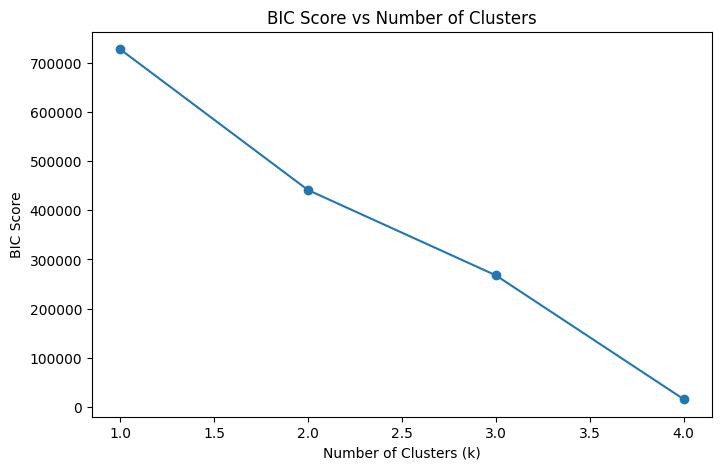

Optimal number of clusters: 4


In [25]:
# Determining Optimal Number of Clusters 
# Code: Find Optimal k

from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt

bic_scores = []
k_range = range(1, 5)

for k in k_range:
    gmm = GaussianMixture(n_components=k, random_state=42)
    gmm.fit(X_scaled)
    bic_scores.append(gmm.bic(X_scaled))

# Plot BIC
plt.figure(figsize=(8,5))
plt.plot(k_range, bic_scores, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("BIC Score")
plt.title("BIC Score vs Number of Clusters")
plt.show()

# Best k
optimal_k = k_range[bic_scores.index(min(bic_scores))]
print("Optimal number of clusters:", optimal_k)

To determine the optimal number of clusters for the Gaussian Mixture Model, the Bayesian Information Criterion (BIC) was evaluated across a range of cluster values from 1 to 4. This restricted range was intentionally chosen based on domain understanding, as it is reasonable to expect only a small number of distinct student profiles influencing job placement outcomes (e.g., high-performing, average, and at-risk students). The BIC scores decreased consistently as the number of clusters increased, with the lowest value observed at k = 4, indicating the best balance between model fit and complexity within the tested range. Although the downward trend suggests that additional clusters may continue to improve model fit, selecting four clusters aligns well with the practical goal of maintaining interpretability while still capturing meaningful variation in student characteristics. Therefore, k = 4 was selected as the optimal number of clusters for the Gaussian Mixture Model in this analysis.

### Train GMM

In [26]:
# Apply Gaussian Mixture Model
# Code: Train GMM

# Train final model
gmm_final = GaussianMixture(n_components=optimal_k, random_state=42)
gmm_final.fit(X_scaled)

# Assign clusters
cluster_labels = gmm_final.predict(X_scaled)

# Add to dataframe
df["GMM_Cluster"] = cluster_labels

# Probabilities (soft clustering insight)
cluster_probs = gmm_final.predict_proba(X_scaled)

### Cluster Evaluation

In [27]:
# Cluster Evaluation 
# Code: Silhouette Score

from sklearn.metrics import silhouette_score

sil_score = silhouette_score(X_scaled, cluster_labels)
print("Silhouette Score:", sil_score)

Silhouette Score: 0.16356260260796077


Cluster quality was evaluated using the Silhouette Score, which measures how well observations are grouped within their assigned clusters compared to other clusters. The Gaussian Mixture Model produced a silhouette score of approximately 0.16, indicating modest separation between clusters. This suggests that while some cluster structure is present, there is still a noticeable degree of overlap among student groups. This result is expected given the nature of the dataset, as student performance and placement readiness tend to exist along a continuum rather than in sharply defined categories. Additionally, because the Gaussian Mixture Model uses probabilistic (soft) clustering, it is inherently designed to handle overlapping data points more effectively than hard clustering methods. Therefore, despite the relatively low silhouette score, the model still provides meaningful insights into underlying student segments and captures the gradual differences in placement readiness across the population.

### Cluster Distribution vs Placement

In [28]:
placement_distribution = pd.crosstab(df["GMM_Cluster"], df["Placement_Status"], normalize="index") * 100
print(placement_distribution)

Placement_Status  Not Placed     Placed
GMM_Cluster                            
0                  98.285752   1.714248
1                  32.089304  67.910696
2                  64.584590  35.415410
3                  29.690049  70.309951


The relationship between cluster membership and placement outcomes was analyzed by examining the distribution of Placement_Status within each Gaussian Mixture Model cluster. The results show clear and meaningful differences across clusters, indicating that the model successfully identified distinct student segments. Clusters 1 and 3 demonstrate high placement rates (approximately 67.9% and 70.3% placed, respectively), suggesting these groups represent well-prepared students with strong academic and communication profiles. In contrast, Cluster 0 exhibits an extremely low placement rate (only 1.7% placed), identifying a group of students who are at significant risk of not securing employment. Cluster 2 shows a more moderate outcome (35.4% placed), representing students who may be borderline in terms of placement readiness. These differences highlight how key features—such as communication skills, CGPA, and backlogs—contribute to separating students into meaningful performance-based groups. Overall, the clustering results provide valuable insight into varying levels of student preparedness and demonstrate the effectiveness of the Gaussian Mixture Model in uncovering patterns related to placement success.

### PCA Visualization

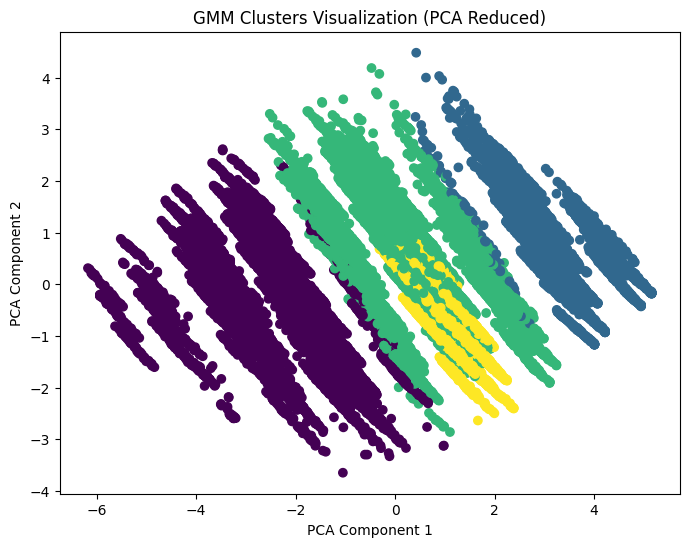

In [29]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=cluster_labels)
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("GMM Clusters Visualization (PCA Reduced)")
plt.show()

To better understand the structure of the clusters identified by the Gaussian Mixture Model, the high-dimensional feature space was reduced to two principal components using Principal Component Analysis (PCA) and visualized in a scatter plot. The resulting visualization shows clusters forming along diagonal bands, indicating strong correlations among the selected features such as communication skills, CGPA, and technical experience. While distinct groupings can be observed, there is also noticeable overlap between clusters, which aligns with the relatively low silhouette score. This overlap suggests that student characteristics do not form sharply separated groups, but rather exist along a continuum of performance and readiness. The visualization reinforces the advantage of using GMM, as it captures these soft boundaries and allows for more flexible cluster assignments compared to rigid clustering methods.

### Conclusion on Gaussian Mixture Model Clustering Method

Overall, the Gaussian Mixture Model proved to be an effective method for uncovering underlying student segments within the dataset. Although the clusters were not perfectly separated, the model successfully identified meaningful groupings that correspond to varying levels of placement success, including high-performing, moderate, and at-risk student profiles. The probabilistic nature of GMM allowed for a more realistic representation of the data, capturing the inherent overlap between student characteristics. These insights are valuable for both educational institutions and students, as they highlight key factors influencing placement outcomes and provide a foundation for targeted interventions. In this context, GMM offered a nuanced and interpretable approach to understanding student readiness beyond traditional classification methods.

## DBSCAN Clustering Analysis (Exceptional Work)

DBSCAN (Density-Based Spatial Clustering of Applications with Noise) is a clustering technqiue that groups data based on density rather than distance to a centroid. Additionally, this method does not require specifying the number of clusters in advance, as it can identify outliers. Using DBSCAN is useful when clusters have irregular shapre or do not belong to any clear group.

In [30]:
#uploading the data and importing the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

In [32]:
#loading data
df = pd.read_csv("full_dataset.csv")

#features selected
features = ['CGPA', 'Internships', 'Projects', 'Certifications', 'Communication_Skills']
X = df[features]

#scaling features
scaler = StandardScaler()
X_Scaled = scaler.fit_transform(X)

### Parameter Selection (K-distance Plot)

The K-distance plot was used to determine a suitable value for eps, which is the radius that DBSCAN uses to decide whether points are close enough to belond to the same dense group. Here the plot shows the distance to the 10th nearest neighbor for each point. Additionally, the plot shows that the curve remaine flat for majority of the points, and then increased sharply towards the end. The "elbow" of the curve was around 0.3-0.4, therefore, eps = 0.35 was selected as it is in the middle of those ranges. A min_sample of 10 was chosen based on five features. Doing these steps ensured that the clusters represent sufficiently dense regions of the data.

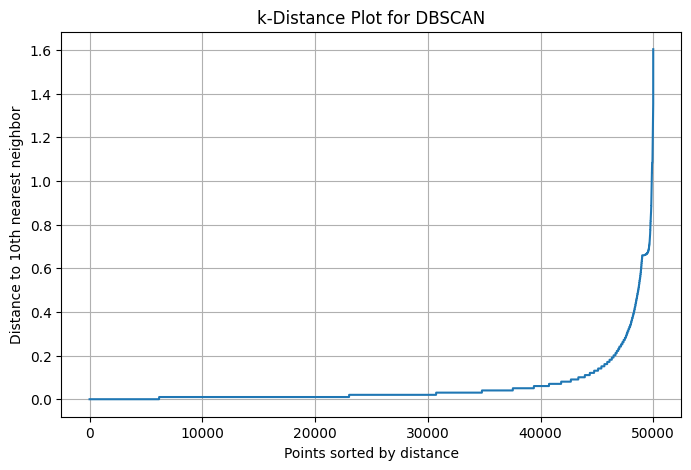

In [33]:
#k-distance plots for eps- radius DBSCAN uses to decide whether the pts are close
min_samples = 10

neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(X_Scaled)
distances,indices = neighbors_fit.kneighbors(X_Scaled)

#Distance to the kth nearest neighbor
K_dist = np.sort(distances[:, -1])

#k-distance plot
plt.figure(figsize=(8, 5))
plt.plot(K_dist)
plt.title("k-Distance Plot for DBSCAN")
plt.xlabel("Points sorted by distance")
plt.ylabel(f"Distance to {min_samples}th nearest neighbor")
plt.grid(True)
plt.show()

### DBSCAN Results

After running the DBSCAN on the data, it summarized the results into 3 sections. The number of clusters that were identified were 190. The number of noise points deteced were 1,263, and there was about 2.53% of noise fraction. Therefore, this all means that the DBSCAN identified many clusters rather than large ones. Additionally, a small percentage of points were classified as noise, meaning that most students belong to some dense groups. Lastly, the larger number of clusters suggested that the data could contain small, tightly grouped students profiles rather than broad segments.

In [34]:
#Fit DBSCAN
eps = 0.35
dbscan = DBSCAN(eps=eps, min_samples=min_samples)
labels = dbscan.fit_predict(X_Scaled)

df["DBSCAN_Cluster"] = labels

#appending the cluster info
n_cluster = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = np.sum(labels == -1)
noise_fraction = n_noise / len(labels)

print("Number of clusters:", n_cluster)
print("Number of noise points:", n_noise)
print("Noise fraction:", round(noise_fraction, 4))

Number of clusters: 190
Number of noise points: 1263
Noise fraction: 0.0253


### Cluster Sizes and Cluster Characteristics

From the results, we found that the cluster sizes vary significantly. Some of the clusters were very large, for exmaple, there were 2,000 students. Other clusters were very small, such as, the less than 100 students that were detected. This indiciated that certain student profiules are very common through the large clusters, and others were rare through the small clusters. The presence of many small clusters reflects that the discrete nature of features like internships, projects, and certifications.

Additionally, we can detect pattern from the large clusters. Many clusters had a CGPA ranging from 6.5-7.2, 0 or 1 internships, 3 to 4 projects, 1 to 2 certifications, and communciation skills between 4 and 7. This suggest that the DBSCAN is grouping students with similar academic and skill profiles into dense regions.

In [35]:
#Cluster sizes
cluster_sizes = pd.Series(labels).value_counts().sort_index()
print("\nCluster sizes:")
print(cluster_sizes.head(20))

#cluster summaries
cluster_summary = (
    df[df["DBSCAN_Cluster"] != -1]
    .groupby("DBSCAN_Cluster")[features]
    .mean()
)

cluster_summary["size"] = (
    df[df["DBSCAN_Cluster"] != -1]
    .groupby("DBSCAN_Cluster")[features]
    .size()
)

print("\nTop 10 largest clusters:")
print(cluster_summary.sort_values(by="size", ascending=False).head(10))


Cluster sizes:
-1     1263
 0     2002
 1      499
 2     1859
 3      919
 4     1861
 5     1124
 6     1187
 7       64
 8       17
 9       54
 10     121
 11     611
 12     672
 13    1899
 14     435
 15     530
 16     117
 17     586
 18     579
Name: count, dtype: int64

Top 10 largest clusters:
                    CGPA  Internships  Projects  Certifications  \
DBSCAN_Cluster                                                    
44              7.147654          0.0       4.0             2.0   
23              7.149961          0.0       4.0             2.0   
0               6.526009          0.0       3.0             1.0   
13              6.545661          0.0       3.0             1.0   
4               7.211891          1.0       4.0             2.0   
2               7.201377          1.0       4.0             2.0   
53              7.181867          0.0       4.0             2.0   
22              7.131990          0.0       4.0             2.0   
25              6.5302

### External Validation with Placement Status

To evaluate the clustering results externally, the DBSCAN cluster labels were compared with the Placement_Status variable using Adjusted Rand Index (ARI) and Normalized Mutual Information (NMI). From this computation, we got an ARI of 0.0152 which is very low. This could have happened because the clusters do not directly matched with the labels that are placed vs no placed. Additionally, we got a NMI of 0.1412 which is low but it is a non-zero. The clustering still captures some meaningful information related to placement. OVerall, the DBSCAN is simply is not seperating students into "placed" and "not placed", instead is captures more detailed patterns in the student profiles.

### Placement Rates by Cluster

Looking at the placement rates within cluster there are some cluster with high placement of around 65% to 69%, while others have 0%. For example, clusters with higher CGPA of around 7.1-7.2 and at least 1 internship shows high placement rates. While clusters with lower CGPA of around 6.5 and no internships shows very low placement rates. This shows that clusters corresponds to meaningful difference in outcomes.

In [36]:
#Using Placement_status after clustering after interpretation
if "Placement_Status" in df.columns:
    y_true = (df["Placement_Status"] == "Placed").astype(int)

#computing Adjusted rand index-measure how similar 2 groups are
    adjusted_rate_index = adjusted_rand_score(y_true, labels)
#computing normalized mutal info - measures the infor the cluster labels give 
    norm_mutual_info = normalized_mutual_info_score(y_true, labels)

    print("\nExternal comparison with Placement_Status")
    print("ARI:", round(adjusted_rate_index, 4))
    print("NMI:", round(norm_mutual_info, 4))

#compute placement rate inside each cluster 
    placement_by_cluster = (
        df[df["DBSCAN_Cluster"] != -1]
        .groupby("DBSCAN_Cluster")["Placement_Status"]
        .apply(lambda s: (s == "Placed").mean())
        .rename("placement_rate")
    )

#joining placement rate with cluster summary 
    final_summary = cluster_summary.join(placement_by_cluster)
    print("\nLargest clusters with placement rates:")
    print(final_summary.sort_values("size", ascending=False).head(10))


External comparison with Placement_Status
ARI: 0.0152
NMI: 0.1412

Largest clusters with placement rates:
                    CGPA  Internships  Projects  Certifications  \
DBSCAN_Cluster                                                    
44              7.147654          0.0       4.0             2.0   
23              7.149961          0.0       4.0             2.0   
0               6.526009          0.0       3.0             1.0   
13              6.545661          0.0       3.0             1.0   
4               7.211891          1.0       4.0             2.0   
2               7.201377          1.0       4.0             2.0   
53              7.181867          0.0       4.0             2.0   
22              7.131990          0.0       4.0             2.0   
25              6.530220          0.0       3.0             1.0   
30              6.527490          0.0       3.0             1.0   

                Communication_Skills  size  placement_rate  
DBSCAN_Cluster             

### PCA Visualization

The PCA plot shows the clusters in two dimensions. We can see that the points are spread across the space without clear large separations. The clusters overlap visually, indicating that separation occurs in higher dimensions. Also the horizontal banding pattern reflects the discrete nature of the features. Therefore, this confirms that DBSCAN is indentifying local density structures rather than large, visually seperable groups.

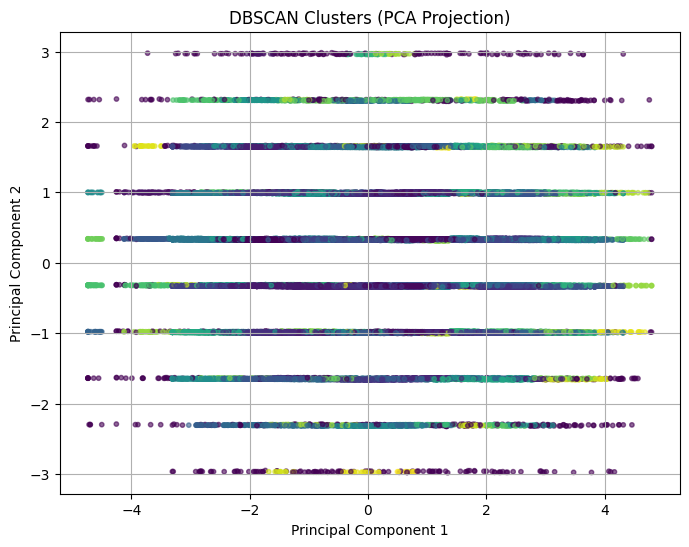

In [37]:
#PCA visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_Scaled)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=labels,
    s=10,
    alpha=0.6
)
plt.title("DBSCAN Clusters (PCA Projection)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.show()

### Important Findings

1. DBSCAN indentified many small, dense clusters indicating diverse student profiles.
2. Only a small percentage of students were classified as outliers.
3. Clusters will higher CGPA and internships tend to have significantly better placement outcomes.
4. Communication skills also appear to influence placement within clusters.
5. The clustering captures meaningful patterns, even though it does not directly align with placement labels.

Overall DBSCAN was effective in identifying detailed subgroups of students based on academic and skill-related features. It revealed meaningful local patterns and highlighted differences in placement outcomes across groups. Therefore, this makes DBSCAN useful for understanding the structure in the dataset.

## Deployment

The clustering models used in this analysis—K-Means, Hierarchical Clustering, Gaussian Mixture Model (GMM), and DBSCAN—provide a way to segment students into meaningful groups based on academic and skill-based attributes. While the goal was to identify clearly separated clusters, evaluation results (e.g., low silhouette scores and overlapping clusters) suggest that student placement readiness exists on a continuum. Therefore, the models are more useful for identifying general student profiles (e.g., high-performing, moderate, at-risk) rather than perfectly distinct groups.

Usefulness for Stakeholders:
* Career centers can use clusters to target interventions:
    *  High-performing clusters → advanced opportunities, networking
    * At-risk clusters → communication training, academic support
    * Moderate clusters → personalized guidance to improve readiness
* Provides more flexibility than classification by focusing on student segments instead of fixed predictions

Deployment Approach
* Integrate into a career services dashboard
* Input student data → assign cluster membership automatically
* Display:
    * Cluster profiles (key characteristics)
    * Historical placement outcomes per cluster
* GMM adds value through probabilistic membership, identifying borderline students

Limitations & Improvements
* Clusters are not strongly separated, limiting precision
* Model utility is best for guidance, not decision-making alone

Additional Data Needed
* Resume quality metrics
* Interview performance
* Networking activity
* Participation in career programs
* Extracurricular involvement

Model Maintenance
* Update every semester or academic year
* Re-evaluate using placement outcomes over time
* Adjust features/model if clusters lose alignment with real results

Although the clustering models do not produce perfectly distinct groups, they provide valuable insights into student segments and can support more targeted and effective career advising strategies.

## Overall Conclusions

This project applied multiple clustering techniques, including K-Means, Hierarchical Clustering, and Gaussian Mixture Models, to analyze patterns in student placement data.

Across all methods, consistent patterns emerged:

- Students with higher CGPA, more internships, and more project experience consistently formed clusters with higher placement rates
- Students with lower academic performance and limited practical experience were grouped into clusters with significantly lower placement outcomes
- Students with moderate profiles showed mixed placement success, indicating that they are on the threshold of employability

While each clustering method grouped the data differently, the overall insights remained consistent. This reinforces the conclusion that academic performance and practical experience are key drivers of placement success.

These findings demonstrate that clustering is an effective approach for uncovering hidden patterns in student data and can be used to support decision-making in education, career development, and recruitment strategies.